# Install and Import necessary libraries

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from pycaret.classification import get_config
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold

# General Settings

In [4]:
DATASET = 'cytotoxicity_data'

RANDOM_STATE = 42
NUM_SPLITS = 10

# Upload Cytotoxicity Data and Create DataFrame

In [7]:
# Load Dataset
model = DATASET
df = pd.read_csv(f'{model}.csv')

In [9]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (436, 76)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'shape_grouped', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_percentage_units', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_percentage_units', 'additive2_use', 'additive3_name', 'additive3_percentage', 'additive3_percentage_units', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'assay_grouped', 'cell_line', 'cell_line_grouped', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'culture_medium_grouped', 'dilution_medium', 'dilution_medium_grouped', 'concentration', 'concentration_units', 'dilution', 'sterilization_method', 'incubation_time', 'incubation_time_units', 'incubation_temperatu

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [12]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'additive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (436, 51)


In [14]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','growth_constant_μ', 'rgr',
              'toxicity_grade','growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (436, 46)


In [16]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type',
                  'additive1_percentage_units',
                  'additive2_percentage_units',
                  'additive3_percentage_units', # derived from cell_line
                  # 'polymer_percentage' # =100-(additive1+additive2+additive3)percentage, it can be omitted as well
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (436, 41)


In [18]:
grouped_pairs = {
    'shape': 'shape_grouped',
    'assay': 'assay_grouped',
    'cell_line': 'cell_line_grouped',
    'culture_medium': 'culture_medium_grouped',
    'dilution_medium': 'dilution_medium_grouped',
    'extraction_medium': 'extraction_medium_grouped',
}

for base_col, grouped_col in grouped_pairs.items():
    if grouped_col in df.columns:
        df[base_col] = df[grouped_col].copy()
        df.drop(columns=[grouped_col], inplace=True)
    else:
        print(f"Skipping missing column: {grouped_col}")

print(df.columns.tolist())

['hb_ratio', 'mw', 'mn', 'pdi', 'shape', 'thickness', 'surface', 'diameter', 'length', 'additive1_percentage', 'additive1_use', 'additive2_percentage', 'additive2_use', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'assay', 'cell_line', 'exposure_type', 'no_cells_per_well', 'culture_medium', 'dilution_medium', 'concentration', 'dilution', 'sterilization_method', 'incubation_time', 'co2_percentage', 'air', 'extraction_dynamics', 'extraction_time', 'extraction_temperature', 'extraction_medium', 'extraction_surface_area_ratio', 'number_of_cells_well', 'toxicity']


# Train/Test Split

In [21]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (13):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - sterilization_method
  - air
  - extraction_dynamics
  - extraction_medium


In [23]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [25]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (327, 34) class proportions toxicity
non-toxic    207
toxic        120
Name: count, dtype: int64

Test size (82, 34) class proportions toxicity
non-toxic    52
toxic        30
Name: count, dtype: int64


In [27]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 327



,Missing Values,Missing Percentage (%)
extraction_dynamics,319,97.6
number_of_cells_well,317,96.9
sterilization_method,309,94.5
surface,305,93.3
length,289,88.4
extraction_medium,282,86.2
extraction_temperature,267,81.7
extraction_surface_area_ratio,267,81.7
extraction_time,267,81.7
thickness,256,78.3


In [29]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (123, 16) class proportions toxicity
non-toxic    70
toxic        53
Name: count, dtype: int64

Test size (31, 16) class proportions toxicity
non-toxic    17
toxic        14
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [33]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    123.000000
mean      92.230894
std        5.702518
min       85.000000
25%       88.000000
50%       90.200000
75%       97.100000
max      100.000000
Name: hb_ratio, dtype: float64


count    123.000000
mean      26.984878
std       17.103533
min        0.000000
25%       12.500000
50%       32.900000
75%       33.330000
max       60.610000
Name: additive1_percentage, dtype: float64


count    123.000000
mean      15.212683
std       15.427955
min        0.000000
25%        0.000000
50%        9.090000
75%       32.900000
max       33.330000
Name: additive2_percentage, dtype: float64


count    123.000000
mean       3.045854
std        6.504017
min        0.000000
25%        0.000000
50%        0.000000
75%        1.320000
max       20.980000
Name: additive3_percentage, dtype: float64


count    123.000000
mean      54.755285
std       30.842972
min       13.990000
25%       32.900000
50%       33.330000
75%       87.500000
max      100.000000
Name: polymer_percentage, dtyp

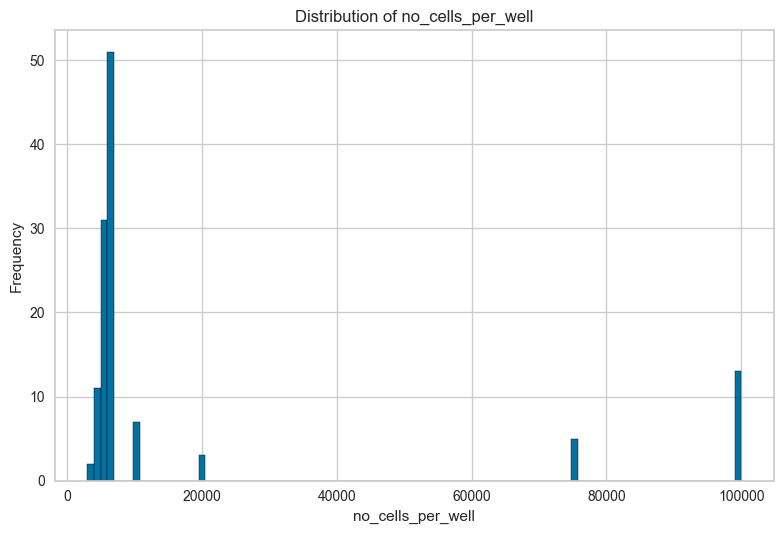



no_cells_per_well
3000.0       2
4000.0      11
5000.0      27
5280.0       4
6000.0      51
10000.0      7
20000.0      3
75000.0      5
100000.0    13
Name: count, dtype: int64


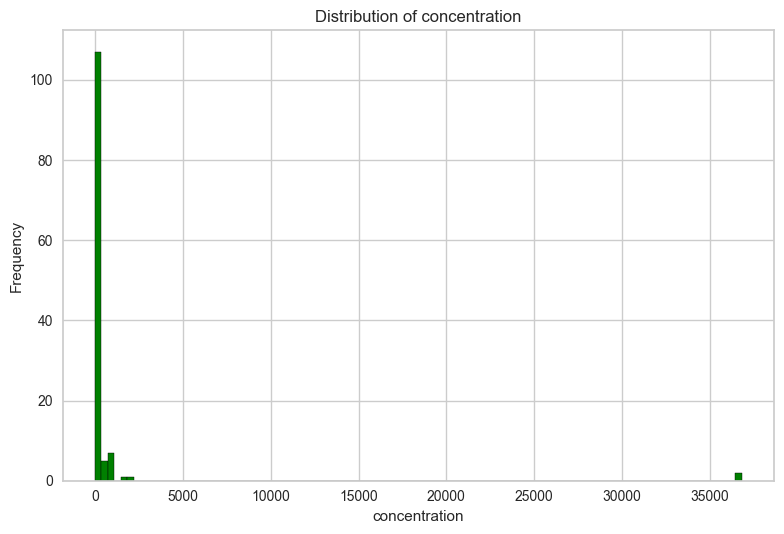



concentration
0.00        10
0.20         8
0.25         4
0.50         4
0.60         7
0.75         4
1.00         5
1.25         3
1.30         9
3.00         9
6.00         8
10.00        2
15.60        3
25.00        4
50.00        4
62.50        2
69.00        5
75.00        1
100.00       9
150.00       1
250.00       4
300.00       1
500.00       4
600.00       1
819.00       3
1000.00      4
1500.00      1
2000.00      1
36800.00     2
Name: count, dtype: int64


In [35]:
# Check heavily skewed features (high value of std)

## Plot a histogram of the distribution of no_cells_per_well
X_train['no_cells_per_well'].hist(bins=100, edgecolor='black')
plt.xlabel('no_cells_per_well')
plt.ylabel('Frequency')
plt.title('Distribution of no_cells_per_well')
plt.tight_layout()
# plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of no_cells_per_well
print('\n')
print(X_train['no_cells_per_well'].value_counts().sort_index())

## Plot a histogram of the distribution of concentration
X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
plt.xlabel('concentration')
plt.ylabel('Frequency')
plt.title('Distribution of concentration')
plt.tight_layout()
# plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of concentration
print('\n')
print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [38]:
# Categorise no_cells_per_wel feature
bins = [0, 10_000, 50_000, float('inf')]
labels = ['low', 'medium', 'high']

X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

Train set: no_cells_per_well
low       102
high       18
medium      3
Name: count, dtype: int64
Test set: no_cells_per_well
low       27
high       3
medium     1
Name: count, dtype: int64


In [40]:
# Categorise concetration
bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['concentration'].value_counts()}")
print(f"\nTest set: {X_test['concentration'].value_counts()}")

Train set: concentration
very_low     44
high         20
low          17
very_high    17
medium       15
zero         10
Name: count, dtype: int64

Test set: concentration
very_low     14
low           7
very_high     4
high          3
zero          2
medium        1
Name: count, dtype: int64


## Outlier Detection

In [43]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


In [45]:
# Check the new categories
for col in X_train.select_dtypes(include=[object]).columns.tolist():
    print("\n")
    print(X_train_clean[col].value_counts())



shape
particulate    93
planar_bulk    19
fibrous        11
Name: count, dtype: int64


additive1_use
functional_or_targeting     78
therapeutic_agent           16
formulation_aid             11
structural_or_mechanical     9
not_applicable               9
Name: count, dtype: int64


additive2_use
stabilizer        51
not_applicable    48
antibiotic        19
activator          5
Name: count, dtype: int64


additive3_use
not_applicable    78
active_drug       26
ceramic_filler    19
Name: count, dtype: int64


assay
metabolic_activity    104
other_endpoint         13
membrane_integrity      5
not_reported            1
Name: count, dtype: int64


cell_line
epithelial_cancer    70
other_or_primary     30
fibroblast           13
immune               10
Name: count, dtype: int64


exposure_type
direct_contact      96
indirect_contact    27
Name: count, dtype: int64


culture_medium
dmem            80
mem_family      22
rpmi_or_hams    21
Name: count, dtype: int64


In [47]:
X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test.reset_index(drop=True)

y_train_clean = y_train_clean.reset_index(drop=True)
y_test_clean  = y_test.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean) == len(y_test_clean)

print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 123 rows | Test: 31 rows


# Feature Selection 

In [50]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (10):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium


## Mutual Information 

In [53]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)
# mi_scores_series.to_excel('../data/mi_scores_cytotoxicity.xlsx')

Mutual Information Scores:
polymer_percentage      0.340286
additive1_percentage    0.332960
additive2_percentage    0.237223
additive3_use           0.166694
additive3_percentage    0.164326
culture_medium          0.124268
hb_ratio                0.121829
concentration           0.121316
additive2_use           0.110757
shape                   0.101951
cell_line               0.083056
assay                   0.053123
additive1_use           0.035459
exposure_type           0.026465
no_cells_per_well       0.023259
incubation_time         0.000000
dtype: float64


## Kendal correlation (Num vs Num)

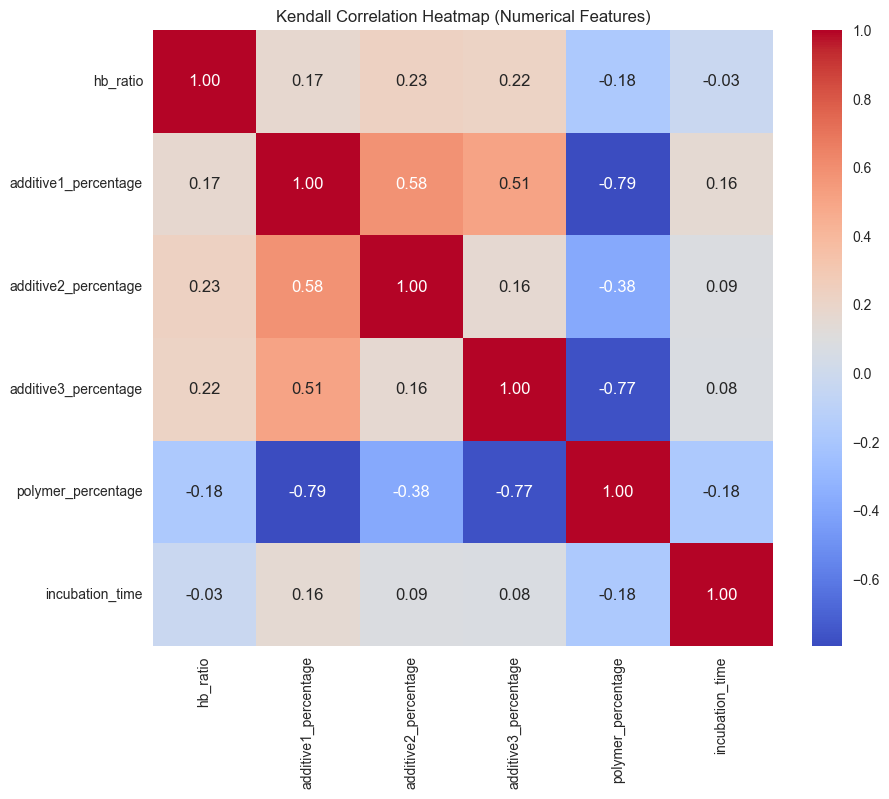

In [56]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
# plt.savefig('../data/Kendall Correlation Heatmap - Cytotoxicity Model.png', dpi=600, bbox_inches='tight')

plt.show()

## Cramér's V (Cat vs Cat)

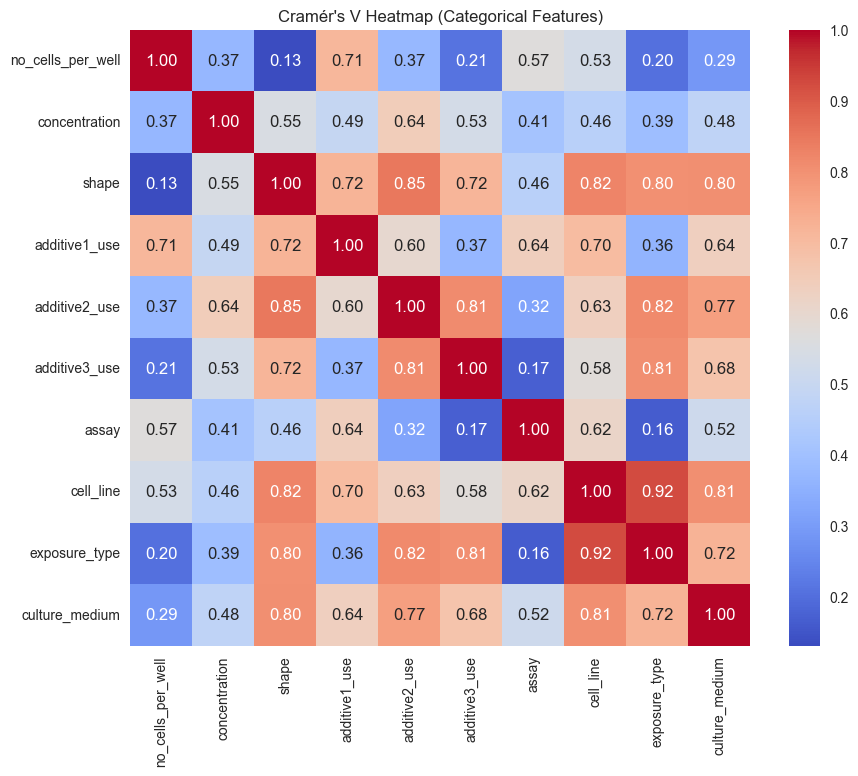

In [59]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [62]:
# feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
# X_train_clean = X_train_clean.drop(columns=feature_to_drop)
# X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
# print(f"Drop feature: {feature_to_drop}") 

# Machine Learning Algorithm

In [65]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (10):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium


In [67]:
# Preprocessing pipeline
def build_preprocessor(features_num, features_cat):
    """
    Returns a fresh, unfitted ColumnTransformer.
    Call this every time you need a new preprocessor instance
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                features_num
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",   
                    sparse_output=False,
                    drop="if_binary"           
                ),
                features_cat
            ),
        ],
        remainder="drop",  # drop any column not explicitly listed
    )

In [69]:
# Preprocessing only for Applicability domain
pre_ad = build_preprocessor(features_num, features_cat)
 
X_train_preprocessed = pre_ad.fit_transform(X_train_clean)
X_test_preprocessed  = pre_ad.transform(X_test_clean)
 
print("\nPreprocessed shapes:")
print(f"  X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"  X_test_preprocessed:  {X_test_preprocessed.shape}")


Preprocessed shapes:
  X_train_preprocessed: (123, 42)
  X_test_preprocessed:  (31, 42)


In [71]:
y_train_clean.value_counts()

toxicity
non-toxic    70
toxic        53
Name: count, dtype: int64

## Pycaret Baseline model

In [74]:
# Built Pycaret's datasets
train_data = X_train_clean.copy()
train_data[target] = y_train_clean.values

test_data_ad = X_test_clean.copy()
test_data_ad[target] = y_test_clean.values


# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data_ad,
            target=target,
            fold=NUM_SPLITS,
            preprocess=True,          
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
            index=False, # not treat the index column as a feature
            session_id=42)

,Description,Value
0,Session id,42
1,Target,toxicity
2,Target type,Binary
3,Target mapping,"non-toxic: 0, toxic: 1"
4,Original data shape,"(154, 17)"
5,Transformed data shape,"(154, 43)"
6,Transformed train set shape,"(123, 43)"
7,Transformed test set shape,"(31, 43)"
8,Numeric features,6
9,Categorical features,10


In [75]:
# Baseline comparison   
baseline = compare_models(sort='mcc', n_select=1)

baseline_results = pull()
print("\n=== BASELINE RANKING (read top 3 from here) ===")
print(baseline_results[['Model', 'MCC', 'AUC', 'Recall', 'F1']].head(3).to_string())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8819,0.9118,0.8819,0.8884,0.8813,0.7586,0.7653,0.1284
gbc,Gradient Boosting Classifier,0.8811,0.9598,0.8811,0.8877,0.8807,0.7579,0.7642,0.1128
ada,Ada Boost Classifier,0.8796,0.9487,0.8796,0.8866,0.8793,0.7558,0.7621,0.1026
qda,Quadratic Discriminant Analysis,0.8626,0.8992,0.8626,0.8782,0.8626,0.7256,0.7383,0.0730
dt,Decision Tree Classifier,0.8649,0.8654,0.8649,0.8726,0.8639,0.7241,0.7319,0.0714
rf,Random Forest Classifier,0.8576,0.9528,0.8576,0.8663,0.8571,0.7113,0.7190,0.1394
lr,Logistic Regression,0.8474,0.9388,0.8474,0.8612,0.8463,0.6921,0.7041,0.2176
lda,Linear Discriminant Analysis,0.8155,0.8678,0.8155,0.8314,0.8147,0.6289,0.6422,0.0704
ridge,Ridge Classifier,0.8130,0.9304,0.8130,0.8290,0.8121,0.6241,0.6373,0.0710
nb,Naive Bayes,0.7186,0.8335,0.7186,0.8231,0.7055,0.4681,0.5449,0.0694



=== BASELINE RANKING (read top 3 from here) ===
                            Model     MCC     AUC  Recall      F1
et         Extra Trees Classifier  0.7653  0.9118  0.8819  0.8813
gbc  Gradient Boosting Classifier  0.7642  0.9598  0.8811  0.8807
ada          Ada Boost Classifier  0.7621  0.9487  0.8796  0.8793


In [77]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(baseline,
                         optimize='mcc',
                         search_library='optuna',
                         n_iter=10,
                         )
# Check the best hyperparameters found
print("Best hyperparameters:", tuned_model.get_params())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9200,0.9903,0.9200,0.9323,0.9203,0.8408,0.8516
1,0.9200,0.9675,0.9200,0.9200,0.9200,0.8377,0.8377
2,0.9600,0.9935,0.9600,0.9627,0.9597,0.9180,0.9211
3,0.8333,0.9357,0.8333,0.8472,0.8345,0.6667,0.6761
4,0.8750,0.9500,0.8750,0.8794,0.8757,0.7465,0.7492
5,0.8800,0.9351,0.8800,0.9057,0.8800,0.7634,0.7857
6,0.8000,0.8539,0.8000,0.8234,0.8000,0.6057,0.6234
7,0.8400,0.9740,0.8400,0.8400,0.8400,0.6753,0.6753
8,0.8750,0.9500,0.8750,0.9038,0.8757,0.7534,0.7774


Best hyperparameters: {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 6, 'max_features': 0.9466060466649395, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0005250851319651679, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 16, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [80]:
predict_model(tuned_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9032,0.9181,0.9032,0.9055,0.9034,0.8058,0.8075


,hb_ratio,additive1_percentage,additive2_percentage,additive3_percentage,polymer_percentage,no_cells_per_well,concentration,incubation_time,shape,additive1_use,additive2_use,additive3_use,assay,cell_line,exposure_type,culture_medium,toxicity,prediction_label,prediction_score
123,85.000000,33.330002,33.330002,0.00,33.330002,low,very_low,48.0,particulate,functional_or_targeting,stabilizer,not_applicable,metabolic_activity,epithelial_cancer,direct_contact,dmem,non-toxic,non-toxic,1.0000
124,85.000000,33.330002,33.330002,0.00,33.330002,low,very_low,24.0,particulate,functional_or_targeting,stabilizer,not_applicable,metabolic_activity,epithelial_cancer,direct_contact,dmem,non-toxic,non-toxic,1.0000
125,88.000000,0.000000,0.000000,0.00,100.000000,high,very_low,24.0,particulate,not_applicable,not_applicable,not_applicable,metabolic_activity,epithelial_cancer,direct_contact,dmem,non-toxic,toxic,0.6752
126,89.500000,0.000000,0.000000,0.00,100.000000,high,very_high,48.0,particulate,not_applicable,not_applicable,not_applicable,other_endpoint,immune,direct_contact,rpmi_or_hams,toxic,toxic,0.8600
127,89.500000,20.299999,0.000000,0.00,79.699997,high,very_high,48.0,particulate,structural_or_mechanical,not_applicable,not_applicable,other_endpoint,immune,direct_contact,rpmi_or_hams,toxic,toxic,0.8600
128,85.000000,32.900002,32.900002,1.32,32.900002,low,low,48.0,particulate,functional_or_targeting,stabilizer,active_drug,metabolic_activity,epithelial_cancer,direct_contact,dmem,toxic,toxic,1.0000
129,97.099998,55.939999,9.090000,20.98,13.990000,low,very_low,48.0,planar_bulk,functional_or_targeting,antibiotic,ceramic_filler,metabolic_activity,other_or_primary,indirect_contact,mem_family,non-toxic,non-toxic,1.0000
130,90.199997,10.000000,0.000000,0.00,90.000000,low,high,48.0,particulate,functional_or_targeting,not_applicable,not_applicable,metabolic_activity,other_or_primary,indirect_contact,dmem,toxic,toxic,0.8097
131,88.000000,0.000000,0.000000,0.00,100.000000,medium,very_high,24.0,particulate,not_applicable,not_applicable,not_applicable,metabolic_activity,other_or_primary,direct_contact,dmem,toxic,toxic,0.6752
132,85.000000,32.900002,32.900002,1.32,32.900002,low,zero,24.0,particulate,functional_or_targeting,stabilizer,active_drug,metabolic_activity,epithelial_cancer,direct_contact,dmem,non-toxic,non-toxic,1.0000


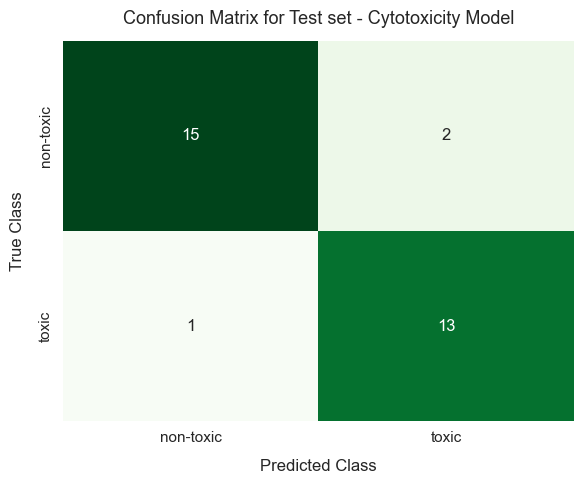

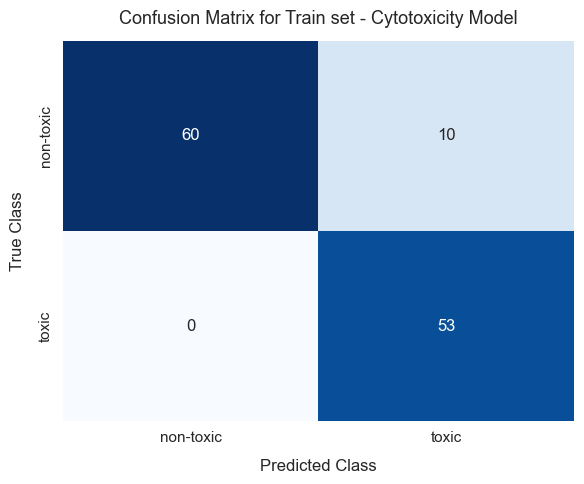

In [82]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    # plt.show()
    plt.show() 
    
predictions = predict_model(tuned_model, data=X_test_clean)

X_test_pred = predictions['prediction_label']  # predicted classes
cm_test = confusion_matrix(y_test_clean, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set - Cytotoxicity Model', 'Greens')

# Same for train
train_predictions = predict_model(tuned_model, data=X_train_clean)
X_train_pred = train_predictions['prediction_label']
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Cytotoxicity Model', 'Blues')

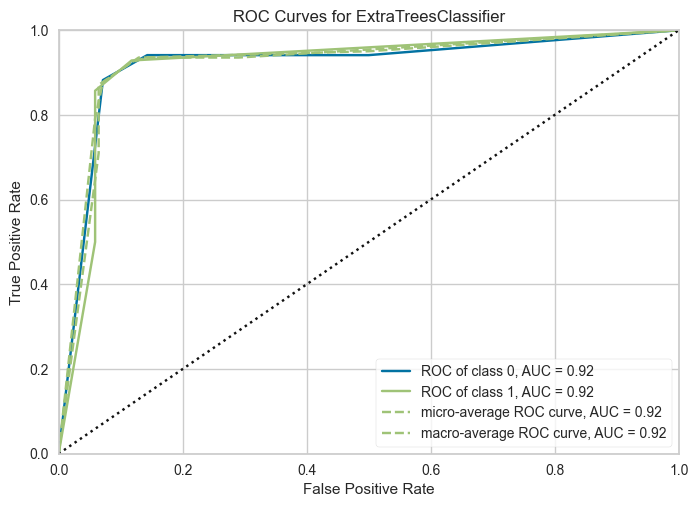

In [84]:
plot_model(tuned_model)

## Metrics

In [170]:
print(X_train_clean.columns.tolist())

['hb_ratio', 'additive1_percentage', 'additive2_percentage', 'additive3_percentage', 'polymer_percentage', 'no_cells_per_well', 'concentration', 'incubation_time', 'shape', 'additive1_use', 'additive2_use', 'additive3_use', 'assay', 'cell_line', 'exposure_type', 'culture_medium']


In [172]:
print(type(tuned_model))

<class 'sklearn.ensemble._forest.ExtraTreesClassifier'>


In [178]:
# train_data here must be the FULL version (with cell_line, exposure_type, shape, polymer_percentage still included)
clf_setup = setup(data=train_data, target=target, session_id=1231)

X_train_transformed = get_config('X_train_transformed')
y_train_transformed = get_config('y_train_transformed')
X_test_transformed = get_config('X_test_transformed')
y_test_transformed = get_config('y_test_transformed')

print(sorted(X_train_transformed.columns.tolist()) == sorted(tuned_model.feature_names_in_.tolist()))  # sanity check — should be True

,Description,Value
0,Session id,1231
1,Target,toxicity
2,Target type,Binary
3,Target mapping,"non-toxic: 0, toxic: 1"
4,Original data shape,"(123, 17)"
5,Transformed data shape,"(123, 43)"
6,Transformed train set shape,"(86, 43)"
7,Transformed test set shape,"(37, 43)"
8,Numeric features,6
9,Categorical features,10


True


In [182]:
X_train_transformed = X_train_transformed[tuned_model.feature_names_in_]
X_test_transformed = X_test_transformed[tuned_model.feature_names_in_]

train_pred = tuned_model.predict(X_train_transformed)
test_pred = tuned_model.predict(X_test_transformed)

train_bal_acc = balanced_accuracy_score(y_train_transformed, train_pred)
train_macro_f1 = f1_score(y_train_transformed, train_pred, average='macro')
test_bal_acc = balanced_accuracy_score(y_test_transformed, test_pred)
test_macro_f1 = f1_score(y_test_transformed, test_pred, average='macro')

print(f"Train | Balanced Accuracy: {train_bal_acc:.4f} | macro-F1: {train_macro_f1:.4f}")
print(f"Test  | Balanced Accuracy: {test_bal_acc:.4f} | macro-F1: {test_macro_f1:.4f}")

Train | Balanced Accuracy: 0.9388 | macro-F1: 0.9299
Test  | Balanced Accuracy: 0.9048 | macro-F1: 0.8918


In [184]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1231)

cv_bal_acc = cross_val_score(tuned_model, X_train_transformed, y_train_transformed, cv=skf, scoring='balanced_accuracy')
cv_macro_f1 = cross_val_score(tuned_model, X_train_transformed, y_train_transformed, cv=skf, scoring='f1_macro')

print(f"CV 5-fold | Balanced Accuracy: {cv_bal_acc.mean():.4f} ± {cv_bal_acc.std():.4f} | macro-F1: {cv_macro_f1.mean():.4f} ± {cv_macro_f1.std():.4f}")
print("Per-fold Balanced Accuracy:", cv_bal_acc)
print("Per-fold macro-F1:", cv_macro_f1)

CV 5-fold | Balanced Accuracy: 0.8932 ± 0.1041 | macro-F1: 0.8798 ± 0.1279
Per-fold Balanced Accuracy: [0.95       0.9375     0.7        0.87857143 1.        ]
Per-fold macro-F1: [0.94427245 0.94035088 0.63571429 0.87857143 1.        ]


# Get Sample Rows for Final Dataset used for Training

In [104]:
sample_df = X_train_clean.copy()
sample_df[target] = y_train_clean
sample_df_fnl = sample_df.sample(20)
print(sample_df_fnl)
sample_df_fnl.to_excel('sample_20_cytotoxicity.xlsx', index=False)

     hb_ratio  additive1_percentage  additive2_percentage  \
26      100.0                 33.33                 33.33   
53      100.0                 32.90                 32.90   
11       85.0                 32.90                 32.90   
84       85.0                 32.90                 32.90   
20       85.0                 33.33                 33.33   
66       88.0                 28.00                  0.00   
40      100.0                 32.90                 32.90   
88       85.0                 32.90                 32.90   
1        94.0                  1.40                  0.00   
72       97.1                 60.61                  9.09   
117      97.1                 60.61                  9.09   
24       89.5                 20.30                  0.00   
103      85.0                 32.90                 32.90   
85      100.0                 32.90                 32.90   
25      100.0                 32.90                 32.90   
91       88.0           

# Final Train and Test Sets

In [106]:
Train_df_fnl = X_train_clean.copy()
Train_df_fnl[target] = y_train_clean
print(Train_df_fnl.sample(20))
Train_df_fnl.to_excel('final_train_set_cytotoxicity.xlsx', index=False)

     hb_ratio  additive1_percentage  additive2_percentage  \
104      85.0                 33.33                 33.33   
33      100.0                 32.90                 32.90   
8        90.2                 20.00                  0.00   
30       89.5                  0.00                  0.00   
0        85.0                 32.90                 32.90   
34       90.2                 10.00                  0.00   
52       97.1                 60.61                  9.09   
31       88.0                  0.84                  0.00   
64       88.0                  0.00                  0.00   
50       88.0                 26.04                  1.96   
23      100.0                 32.90                 32.90   
96       85.0                 33.33                 33.33   
76      100.0                 33.33                 33.33   
21       85.0                 32.90                 32.90   
38       89.5                  0.00                  0.00   
48      100.0           

In [108]:
Test_df_fnl = X_test_clean.copy()
Test_df_fnl[target] = y_test_clean
print(Test_df_fnl.sample(20))
Test_df_fnl.to_excel('final_test_set_cytotoxicity.xlsx', index=False)

    hb_ratio  additive1_percentage  additive2_percentage  \
29     100.0                 32.90                 32.90   
20      88.0                  0.84                  0.00   
7       90.2                 10.00                  0.00   
0       85.0                 33.33                 33.33   
18      85.0                 32.90                 32.90   
13     100.0                 32.90                 32.90   
2       88.0                  0.00                  0.00   
16      85.0                 32.90                 32.90   
6       97.1                 55.94                  9.09   
26      85.0                 33.33                 33.33   
23      85.0                 33.33                 33.33   
9       85.0                 32.90                 32.90   
15      85.0                 33.33                 33.33   
1       85.0                 33.33                 33.33   
11      88.0                  0.84                  0.00   
12      85.0                 32.90      

In [149]:
from pycaret.classification import setup

cols_to_drop = ['polymer_percentage', 'shape', 'cell_line', 'exposure_type']
df_test = Train_df_fnl.drop(columns=cols_to_drop)

clf_setup = setup(
    data=df_test,          # your training dataframe
    target='toxicity',     # your target column
    session_id=1231,       # match jaqpot_model.random_seed for reproducibility
)

,Description,Value
0,Session id,1231
1,Target,toxicity
2,Target type,Binary
3,Target mapping,"non-toxic: 0, toxic: 1"
4,Original data shape,"(123, 13)"
5,Transformed data shape,"(123, 34)"
6,Transformed train set shape,"(86, 34)"
7,Transformed test set shape,"(37, 34)"
8,Numeric features,5
9,Categorical features,7


In [151]:
JAQPOT_COMPATIBLE_CLASSIFIERS = [
    'AdaBoostClassifier',
    'BaggingClassifier',
    'BernoulliNB',
    'CalibratedClassifierCV',
    'CategoricalNB',
    'ComplementNB',
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GaussianNB',
    'GaussianProcessClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'KNeighborsClassifier',
    'LinearSVC',
    'LogisticRegression',       
    'MLPClassifier',
    'MultinomialNB',
    'OneVsOneClassifier',
    'OneVsRestClassifier',
    'QuadraticDiscriminantAnalysis',
    'RadiusNeighborsClassifier',
    'RandomForestClassifier',
    'SGDClassifier',
    'SVC',
    'StackingClassifier',
    'VotingClassifier',
    'RidgeClassifier',           
    'LinearDiscriminantAnalysis', 
]

# Tree-based models: capture non-linear relationships in small heterogeneous
# datasets and support exact SHAP computation via TreeExplainer
TREE_BASED_CLASSIFIERS = {
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'RandomForestClassifier',
}

In [153]:
best_results = compare_models(sort='mcc', n_select=5)
chosen_model = None

for m in best_results:
    if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS and type(m).__name__ in TREE_BASED_CLASSIFIERS:
        chosen_model = m
        break
if chosen_model is None:
    for m in best_results:
        if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS:
            chosen_model = m
            break

tuned_chosen = tune_model(chosen_model, optimize='mcc', search_library='optuna', n_iter=10)
final_model = type(tuned_chosen)(**tuned_chosen.get_params())

import joblib
joblib.dump(final_model, 'final_model.pkl')
print("Model saved for jaqpot notebook")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8972,0.8600,0.8972,0.9098,0.8973,0.7930,0.8040,0.0530
qda,Quadratic Discriminant Analysis,0.8694,0.8567,0.8694,0.9080,0.8679,0.7504,0.7772,0.0550
gbc,Gradient Boosting Classifier,0.8750,0.9308,0.8750,0.8953,0.8737,0.7523,0.7688,0.0910
ridge,Ridge Classifier,0.8625,0.8917,0.8625,0.8856,0.8613,0.7302,0.7473,0.0680
ada,Ada Boost Classifier,0.8611,0.9204,0.8611,0.8827,0.8597,0.7206,0.7397,0.0960
et,Extra Trees Classifier,0.8389,0.9108,0.8389,0.8726,0.8356,0.6876,0.7111,0.1170
rf,Random Forest Classifier,0.8389,0.9525,0.8389,0.8664,0.8372,0.6822,0.7038,0.1360
lr,Logistic Regression,0.8167,0.8717,0.8167,0.8636,0.8098,0.6400,0.6764,0.6650
dt,Decision Tree Classifier,0.8264,0.8550,0.8264,0.8504,0.8246,0.6482,0.6701,0.0690
nb,Naive Bayes,0.6569,0.8383,0.6569,0.7568,0.6164,0.3781,0.4617,0.0550


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7778,1.0000,0.7778,0.8413,0.7593,0.5263,0.5976
1,0.5556,0.6000,0.5556,0.5926,0.5444,0.1429,0.1581
2,0.7778,0.8500,0.7778,0.7778,0.7778,0.5500,0.5500
3,0.8889,0.8000,0.8889,0.9111,0.8889,0.7805,0.8000
4,0.8889,1.0000,0.8889,0.9111,0.8889,0.7805,0.8000
5,0.8889,0.9500,0.8889,0.9074,0.8860,0.7692,0.7906
6,0.8750,1.0000,0.8750,0.9000,0.8730,0.7500,0.7746
7,0.8750,1.0000,0.8750,0.9062,0.8770,0.7500,0.7746
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Model saved for jaqpot notebook


## SHAP plot

In [121]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [125]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (123, 43)
X_test_final shape: (31, 43)


In [127]:
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

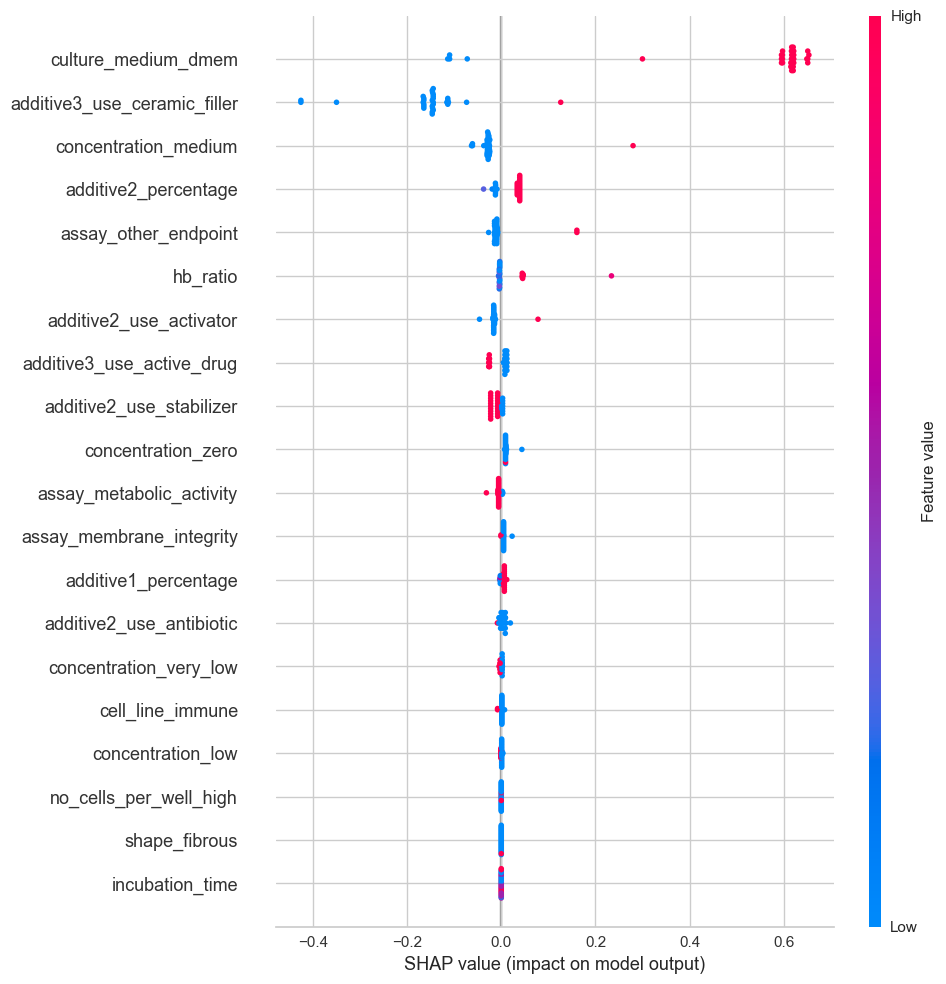

In [141]:
sv0 = shap_values[:, :, 0]   # SHAP values for "toxic" predictions

shap.summary_plot(
    sv0,
    X_test_final,
    #    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(10, 10)
)
plt.tight_layout()
plt.savefig("cytotoxicity_toxic_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

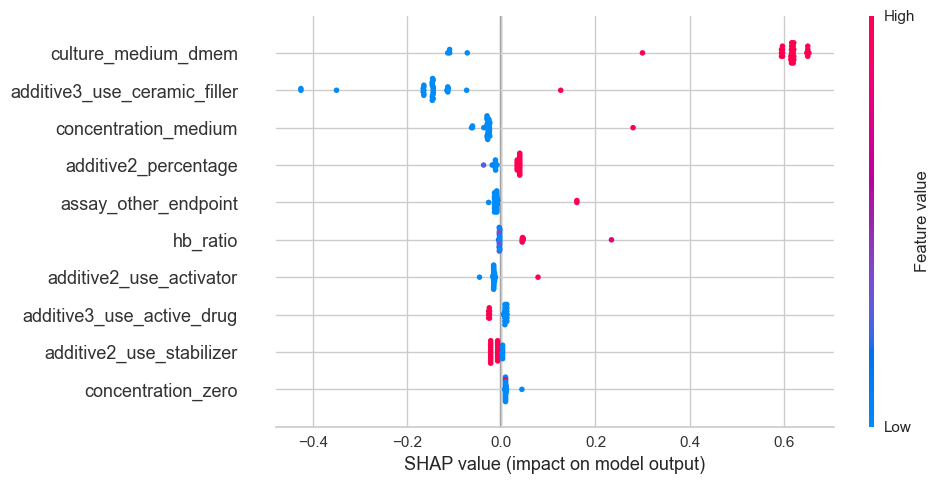

In [147]:
shap.summary_plot(
    sv0,
    X_test_final,
    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)
plt.tight_layout()
plt.savefig("cytotoxicity_toxic_shap10.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

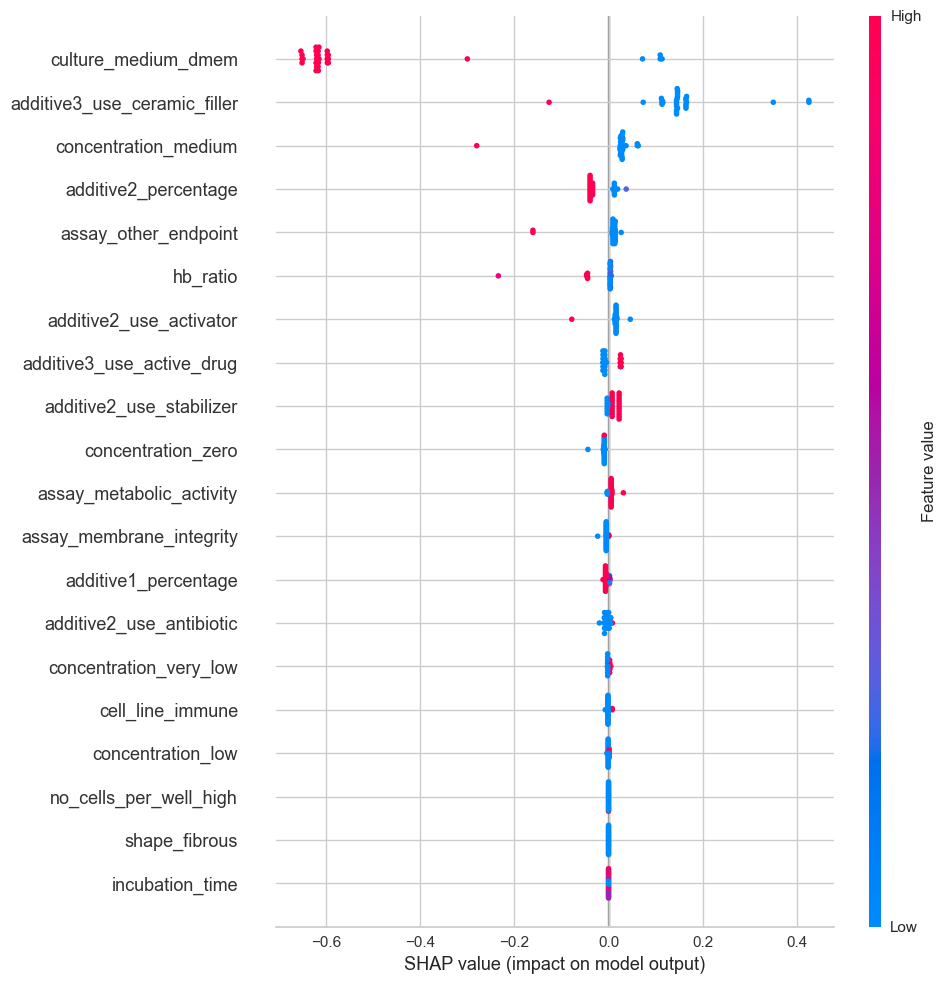

In [143]:
sv1 = shap_values[:, :, 1]   # SHAP values for "toxic" predictions

shap.summary_plot(
    sv1,
    X_test_final,
    show=False,
    plot_size=(10, 10)
)
plt.tight_layout()
plt.savefig("cytotoxicity_nontoxic_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

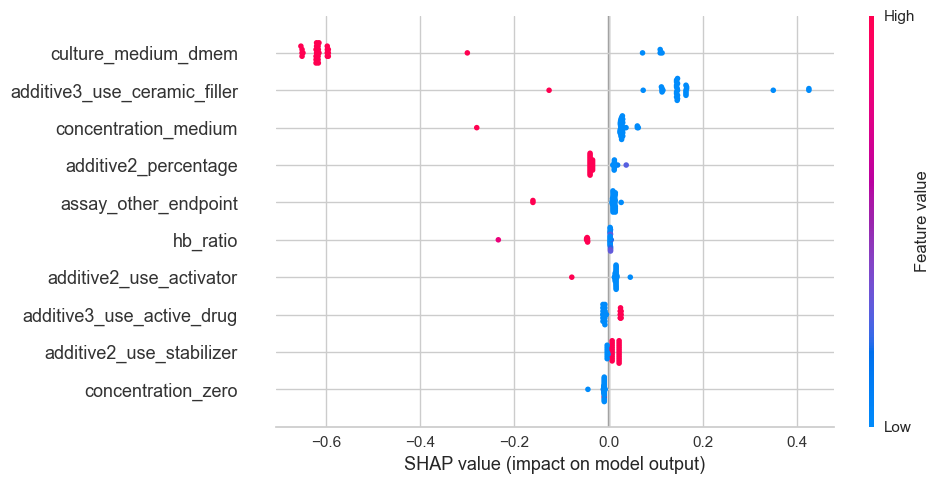

In [157]:
shap.summary_plot(
    sv1,
    X_test_final,
    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)
plt.tight_layout()
plt.savefig("cytotoxicity_nontoxic_shap10.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()